In [ ]:
# Step 1: Import necessary libraries
import pandas as pd

# Step 2: Load the dataset
file_path = '/boot/Fifa 23 Players Data.csv'
df = pd.read_csv(file_path)

# Step 3: Display the first 5 rows of the dataframe
df.head()


,Known As,Full Name,Overall,Potential,Value(in Euro),Positions Played,Best Position,Nationality,Image Link,Age,...,LM Rating,CM Rating,RM Rating,LWB Rating,CDM Rating,RWB Rating,LB Rating,CB Rating,RB Rating,GK Rating
0,L. Messi,Lionel Messi,91,91,54000000,RW,CAM,Argentina,https://cdn.sofifa.net/players/158/023/23_60.png,35,...,91,88,91,67,66,67,62,53,62,22
1,K. Benzema,Karim Benzema,91,91,64000000,"CF,ST",CF,France,https://cdn.sofifa.net/players/165/153/23_60.png,34,...,89,84,89,67,67,67,63,58,63,21
2,R. Lewandowski,Robert Lewandowski,91,91,84000000,ST,ST,Poland,https://cdn.sofifa.net/players/188/545/23_60.png,33,...,86,83,86,67,69,67,64,63,64,22
3,K. De Bruyne,Kevin De Bruyne,91,91,107500000,"CM,CAM",CM,Belgium,https://cdn.sofifa.net/players/192/985/23_60.png,31,...,91,91,91,82,82,82,78,72,78,24
4,K. Mbappé,Kylian Mbappé,91,95,190500000,"ST,LW",ST,France,https://cdn.sofifa.net/players/231/747/23_60.png,23,...,92,84,92,70,66,70,66,57,66,21


In [ ]:
# Step 1: Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Step 2: Drop irrelevant columns (e.g., image links, player names, club names, etc.)
irrelevant_columns = ['Known As', 'Full Name', 'Nationality', 'Image Link', 'Club Name', 'National Team Name',
                      'National Team Image Link', 'Club Position', 'National Team Position']
df_cleaned = df.drop(columns=irrelevant_columns)

# Step 3: Handle missing values (Drop rows with missing values)
df_cleaned = df_cleaned.dropna()

# Step 4: Convert categorical features to numeric (if needed)
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns

# Convert each categorical column to numeric using Label Encoding
for col in categorical_columns:
    label_encoder = LabelEncoder()
    df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

# Step 5: Display the cleaned data and check if there are still missing values
print("\nCleaned Data Overview:")
print(df_cleaned.info())
print("\nFirst 5 rows of the cleaned dataframe:")
df_cleaned.head()


Missing values in each column:
 Known As          0
Full Name         0
Overall           0
Potential         0
Value(in Euro)    0
                 ..
RWB Rating        0
LB Rating         0
CB Rating         0
RB Rating         0
GK Rating         0
Length: 89, dtype: int64

Cleaned Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 80 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Overall                      18539 non-null  int64
 1   Potential                    18539 non-null  int64
 2   Value(in Euro)               18539 non-null  int64
 3   Positions Played             18539 non-null  int64
 4   Best Position                18539 non-null  int64
 5   Age                          18539 non-null  int64
 6   Height(in cm)                18539 non-null  int64
 7   Weight(in kg)                18539 non-null  int64
 8   TotalStats               

,Overall,Potential,Value(in Euro),Positions Played,Best Position,Age,Height(in cm),Weight(in kg),TotalStats,BaseStats,...,LM Rating,CM Rating,RM Rating,LWB Rating,CDM Rating,RWB Rating,LB Rating,CB Rating,RB Rating,GK Rating
0,91,91,54000000,556,0,35,169,67,2190,452,...,91,88,91,67,66,67,62,53,62,22
1,91,91,64000000,153,3,34,185,81,2147,455,...,89,84,89,67,67,67,63,58,63,21
2,91,91,84000000,644,14,33,185,81,2205,458,...,86,83,86,67,69,67,64,63,64,22
3,91,91,107500000,160,4,31,181,70,2303,483,...,91,91,91,82,82,82,78,72,78,24
4,91,95,190500000,671,14,23,182,73,2177,470,...,92,84,92,70,66,70,66,57,66,21


In [ ]:
# Step 1: Select relevant feature columns (statistical columns for player attributes)
relevant_columns = ['Overall', 'Potential', 'Age', 'Height(in cm)', 'Weight(in kg)',
                    'Pace Total', 'Shooting Total', 'Passing Total', 'Dribbling Total',
                    'Defending Total', 'Physicality Total', 'Crossing', 'Finishing',
                    'Heading Accuracy', 'Short Passing', 'Volleys', 'Dribbling', 'Curve',
                    'Freekick Accuracy', 'LongPassing', 'BallControl', 'Acceleration',
                    'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Shot Power',
                    'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Aggression',
                    'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
                    'Marking', 'Standing Tackle', 'Sliding Tackle']
df_features = df_cleaned[relevant_columns]

# Step 2: Normalize the features to have values between 0 and 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

# Step 3: Display the normalized data and verify
print("\nNormalized Data Overview:")
print(df_normalized.info())
print("\nFirst 5 rows of the normalized dataframe:")
df_normalized.head()



Normalized Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Overall            18539 non-null  float64
 1   Potential          18539 non-null  float64
 2   Age                18539 non-null  float64
 3   Height(in cm)      18539 non-null  float64
 4   Weight(in kg)      18539 non-null  float64
 5   Pace Total         18539 non-null  float64
 6   Shooting Total     18539 non-null  float64
 7   Passing Total      18539 non-null  float64
 8   Dribbling Total    18539 non-null  float64
 9   Defending Total    18539 non-null  float64
 10  Physicality Total  18539 non-null  float64
 11  Crossing           18539 non-null  float64
 12  Finishing          18539 non-null  float64
 13  Heading Accuracy   18539 non-null  float64
 14  Short Passing      18539 non-null  float64
 15  Volleys            18539 non-null  float64


,Overall,Potential,Age,Height(in cm),Weight(in kg),Pace Total,Shooting Total,Passing Total,Dribbling Total,Defending Total,...,Long Shots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,Standing Tackle,Sliding Tackle
0,1.0,0.914894,0.678571,0.274510,0.321429,0.768116,0.960526,0.955882,1.000000,0.250000,...,1.000000,0.400000,0.420455,0.968085,1.000000,0.802326,1.000000,0.191011,0.333333,0.214286
1,1.0,0.914894,0.642857,0.588235,0.571429,0.753623,0.947368,0.852941,0.893939,0.315789,...,0.873563,0.623529,0.409091,0.957447,0.940476,0.906977,0.927711,0.449438,0.206897,0.142857
2,1.0,0.914894,0.607143,0.588235,0.571429,0.681159,0.986842,0.794118,0.878788,0.381579,...,0.919540,0.835294,0.522727,0.978723,0.845238,0.976744,0.903614,0.359551,0.413793,0.154762
3,1.0,0.914894,0.535714,0.509804,0.375000,0.666667,0.947368,1.000000,0.893939,0.644737,...,1.000000,0.764706,0.715909,0.914894,1.000000,0.895349,0.915663,0.730337,0.678161,0.559524
4,1.0,1.000000,0.250000,0.529412,0.428571,1.000000,0.960526,0.808824,0.969697,0.276316,...,0.896552,0.635294,0.397727,0.957447,0.869048,0.860465,0.903614,0.258427,0.321839,0.309524


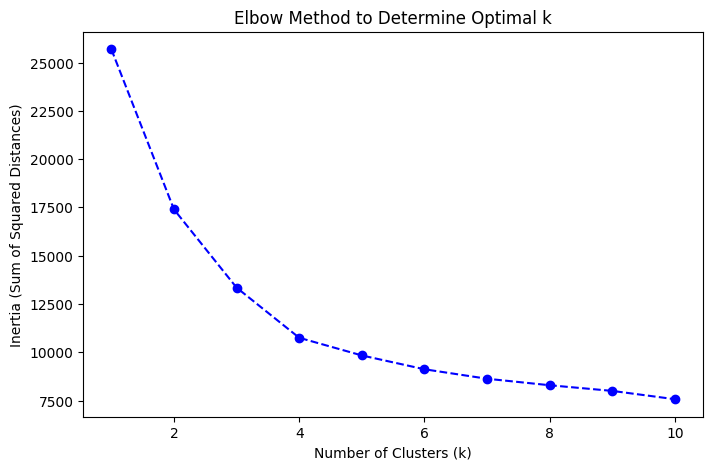

In [ ]:
# Step 1: Import necessary libraries for clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 2: Determine the optimal number of clusters using the Elbow Method
inertia_values = []
k_range = range(1, 11)  # Checking for k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_normalized)
    inertia_values.append(kmeans.inertia_)

# Step 3: Plot the Elbow curve to visualize the optimal k
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method to Determine Optimal k')
plt.show()


<ipython-input-5-41c9bcf28129>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='viridis')


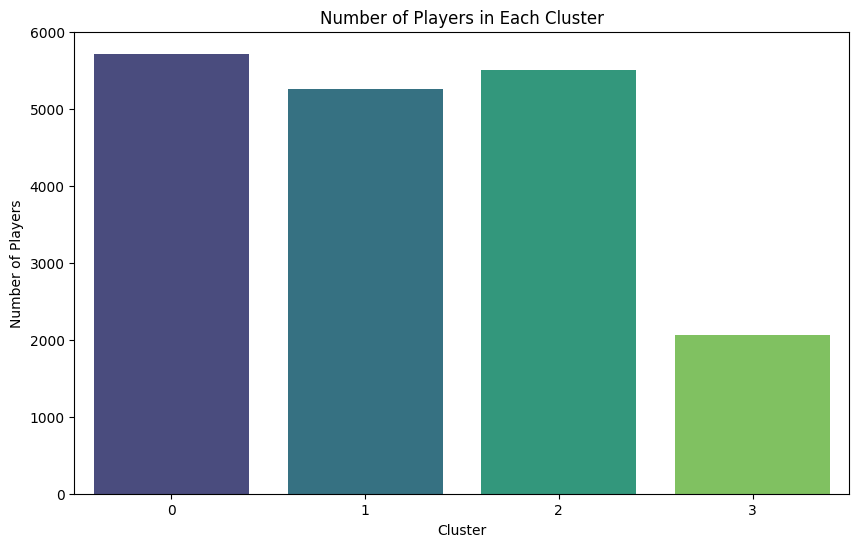

In [ ]:
# Step 1: Apply K-Means clustering with the optimal number of clusters
optimal_k = 4  # Replace 4 with the k you chose based on the elbow curve
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_normalized)  # Add cluster labels to the original dataframe

# Step 2: Display the first few rows of the dataframe to check the cluster assignment
df.head()

# Step 3: Visualize the distribution of clusters
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=df, palette='viridis')
plt.title('Number of Players in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Players')
plt.show()


In [ ]:
# Step 1: Import necessary libraries for classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 2: Select features and target variable for classification
X = df[['Cluster', 'Pace Total', 'Shooting Total', 'Passing Total', 'Dribbling Total',
        'Defending Total', 'Physicality Total']]  # Features for classification
y = df['Best Position']  # Target variable

# Step 3: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Initialize and train the KNN classifier (with k=5)
knn = KNeighborsClassifier(n_neighbors=5)  # You can change n_neighbors to fine-tune performance
knn.fit(X_train, y_train)

# Step 5: Make predictions on the test set
y_pred = knn.predict(X_test)

# Step 6: Evaluate the performance of the KNN classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN Classification Accuracy: {accuracy:.2f}')

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


KNN Classification Accuracy: 0.61

Classification Report:
              precision    recall  f1-score   support

         CAM       0.47      0.69      0.56       420
          CB       0.81      0.90      0.86       691
         CDM       0.47      0.54      0.50       300
          CF       0.50      0.13      0.21        15
          CM       0.49      0.53      0.51       222
          GK       0.86      0.93      0.90       451
          LB       0.30      0.28      0.29       180
          LM       0.24      0.21      0.22       136
          LW       0.10      0.04      0.06        50
         LWB       0.22      0.14      0.17        86
          RB       0.30      0.21      0.25       195
          RM       0.39      0.31      0.34       281
          RW       0.27      0.05      0.09        74
         RWB       0.18      0.07      0.10        86
          ST       0.88      0.82      0.85       521

    accuracy                           0.61      3708
   macro avg       0.4

In [ ]:
# Step 1: Import necessary libraries for Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# Step 2: Select features and target variable for classification (reusing previous features)
X = df[['Cluster', 'Pace Total', 'Shooting Total', 'Passing Total', 'Dribbling Total',
        'Defending Total', 'Physicality Total']]  # Features for classification
y = df['Best Position']  # Target variable

# Step 3: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Initialize and train the Gradient Boosting classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# You can tune these hyperparameters to improve performance

# Step 5: Train the model on the training data
gbc.fit(X_train, y_train)

# Step 6: Make predictions on the test set
y_pred = gbc.predict(X_test)

# Step 7: Evaluate the performance of the Gradient Boosting classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Gradient Boosting Classification Accuracy: {accuracy:.2f}')

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Gradient Boosting Classification Accuracy: 0.66

Classification Report:
              precision    recall  f1-score   support

         CAM       0.55      0.73      0.63       420
          CB       0.84      0.90      0.87       691
         CDM       0.55      0.60      0.58       300
          CF       0.00      0.00      0.00        15
          CM       0.57      0.67      0.62       222
          GK       1.00      1.00      1.00       451
          LB       0.22      0.19      0.21       180
          LM       0.26      0.07      0.11       136
          LW       0.12      0.02      0.03        50
         LWB       0.13      0.05      0.07        86
          RB       0.30      0.33      0.31       195
          RM       0.44      0.50      0.47       281
          RW       0.20      0.03      0.05        74
         RWB       0.13      0.06      0.08        86
          ST       0.88      0.92      0.90       521

    accuracy                           0.66      3708
   macro

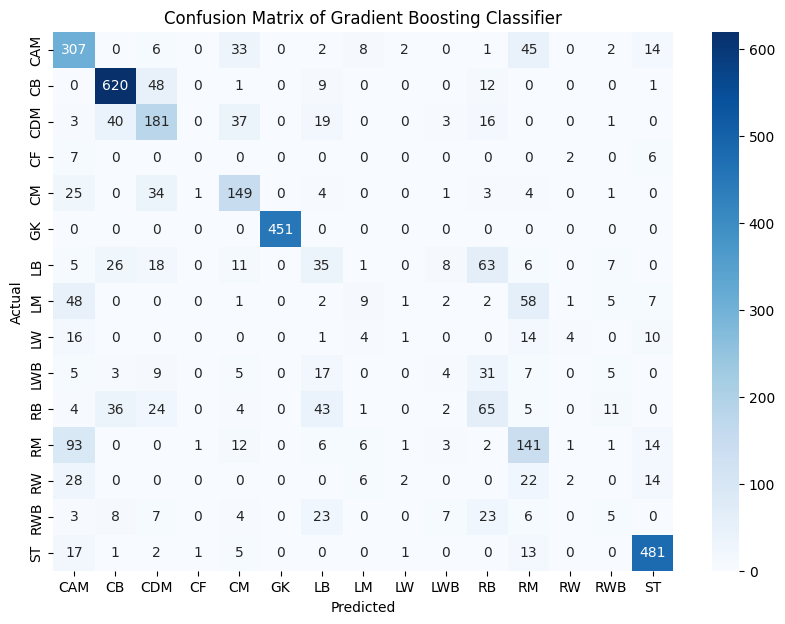

<ipython-input-8-33c28a84f730>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


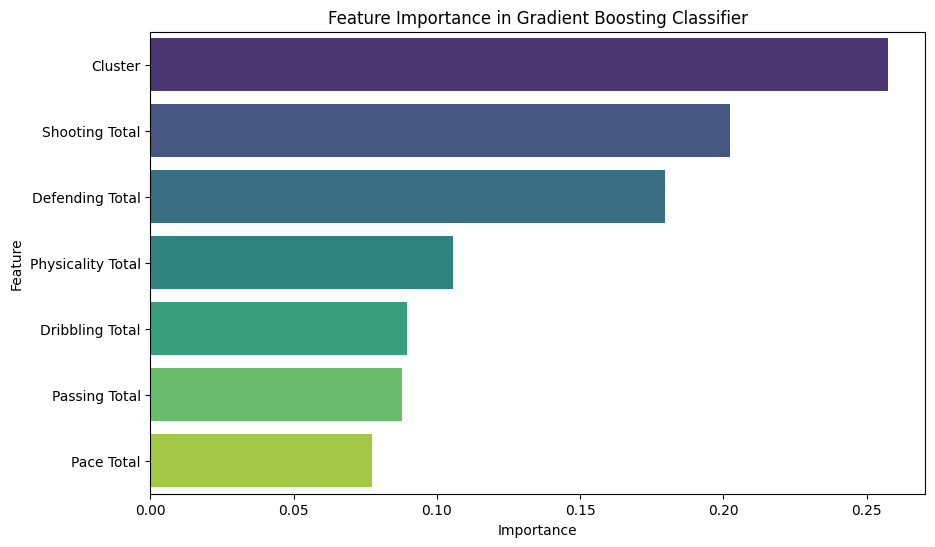

Project Complete ✅
The trained Gradient Boosting model has been saved as 'gradient_boosting_model.pkl'.

🔍 Key Takeaways:
1️⃣ Final Classification Accuracy: 0.66
2️⃣ Check the confusion matrix to see how well the model predicted each position.
3️⃣ Feature importance analysis shows the most influential skills for position prediction.


In [ ]:
# Step 1: Import libraries for evaluation and visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 2: Create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 3: Plot the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', xticklabels=gbc.classes_, yticklabels=gbc.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Gradient Boosting Classifier')
plt.show()

# Step 4: Feature Importance Analysis
feature_importance = gbc.feature_importances_
feature_names = X.columns

# Create a DataFrame to visualize feature importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance in Gradient Boosting Classifier')
plt.show()

# Step 5: Save the trained Gradient Boosting model for future use
import pickle
with open('/content/gradient_boosting_model.pkl', 'wb') as file:
    pickle.dump(gbc, file)

print("Project Complete ✅")
print("The trained Gradient Boosting model has been saved as 'gradient_boosting_model.pkl'.")

# Step 6: Final Messages
print("\n🔍 Key Takeaways:")
print(f"1️⃣ Final Classification Accuracy: {accuracy:.2f}")
print("2️⃣ Check the confusion matrix to see how well the model predicted each position.")
print("3️⃣ Feature importance analysis shows the most influential skills for position prediction.")
